*Credits: materials from this notebook belong to YSDA [Practical DL](https://github.com/yandexdataschool/Practical_DL) course. Special thanks for making them available online.*

# Lab assignment №1, part 1

This lab assignment consists of several parts. You are supposed to make some transformations, train some models, estimate the quality of the models and explain your results.

Several comments:
* Don't hesitate to ask questions, it's a good practice.
* No private/public sharing, please. The copied assignments will be graded with 0 points.
* Blocks of this lab will be graded separately.

## 1. Matrix differentiation

Since it easy to google every task please please please try to undestand what's going on. The "just answer" thing will be not counted, make sure to present derivation of your solution. It is absolutely OK if you found an answer on web then just exercise in $\LaTeX$ copying it into here.

Useful links: 
[1](http://www.machinelearning.ru/wiki/images/2/2a/Matrix-Gauss.pdf)
[2](http://www.atmos.washington.edu/~dennis/MatrixCalculus.pdf)

## ex. 1

$$  
y = x^Tx,  \quad x \in \mathbb{R}^N 
$$

$$
\frac{dy}{dx} = 
$$ 

$$dy=d(x^{T}x)$$

Согласно правилам преобразования
$$d(X,Y)=(dX)Y+X(dY)$$

$$dy=d(x^{T}x)=d(x^T)x+x^T(dx)=2x^Tdx$$
$$\frac{dy}{dx}=2x^T$$

## ex. 2

$$ y = tr(AB) \quad A,B \in \mathbb{R}^{N \times N} $$ 

$$
\frac{dy}{dA} =
$$

In [3]:
# The Matrix Cookbook - page 12

$$\frac{d}{dX}Tr(XA)=A^T$$

$$\frac{dy}{dA} =\frac{d}{dA}tr(AB)=B^T$$

## ex. 3

$$  
y = x^TAc , \quad A\in \mathbb{R}^{N \times N}, x\in \mathbb{R}^{N}, c\in \mathbb{R}^{N} 
$$

$$
\frac{dy}{dx} = d(x^TAc)=|Ac=g|=d(x^Tg)=(dx)^Tg=g^Tdx=(Ac)^Tdx
$$
Запишем в виде градиента (как вектор-столбец):
$$\frac{dy}{dx}=Ac$$

$$
\frac{dy}{dA} =
$$ 

Hint for the latter (one of the ways): use *ex. 2* result and the fact 
$$
tr(ABC) = tr (CAB)
$$

In [2]:
# не понял, как использовать подсказку, решим в лоб

$$\displaystyle y=x^TAc=(x_1, \dots, x_n)
\begin{pmatrix}
a_{11} & \cdots & a_{1n} \\
\vdots & \ddots & \vdots \\
a_{n1} & \cdots & a_{nn}
\end{pmatrix}\begin{pmatrix}
c_1 \\
\vdots \\
c_{n}
\end{pmatrix}=(x_1, \dots, x_n)\begin{pmatrix}
\sum_{j=1}^{n}a_{1j}c_j \\
\vdots \\
\sum_{j=1}^{n}a_{nj}c_j
\end{pmatrix}=x_1 \sum_{j=1}^{n}a_{1j}c_j+\dots+x_n \sum_{j=1}^{n}a_{nj}c_j$$

$$\frac{dy}{d(a_{ij})}=\frac{\partial (x_1 \sum_{j=1}^{n}a_{1j}c_j+\dots+x_n \sum_{j=1}^{n}a_{nj}c_j)}{\partial{(a_{ij})}}=c^Tx$$

## ex. 4

Classic matrix factorization example. Given matrix $X$ you need to find $A$, $S$ to approximate $X$. This can be done by simple gradient descent iteratively alternating $A$ and $S$ updates.
$$
J = || X - AS ||_F^2  , \quad A\in \mathbb{R}^{N \times R} , \quad S\in \mathbb{R}^{R \times M}
$$
$$
\frac{dJ}{dS} = ? 
$$

You may use one of the following approaches:

#### First approach
Using ex.2 and the fact:
$$
|| X ||_F^2 = tr(XX^T) 
$$ 
it is easy to derive gradients (you can find it in one of the refs). 

#### Second approach
You can use *slightly different techniques* if they suits you. Take a look at this derivation:
<img src="grad.png">
(excerpt from [Handbook of blind source separation, Jutten, page 517](https://books.google.ru/books?id=PTbj03bYH6kC&printsec=frontcover&dq=Handbook+of+Blind+Source+Separation&hl=en&sa=X&ved=0ahUKEwi-q_apiJDLAhULvXIKHVXJDWcQ6AEIHDAA#v=onepage&q=Handbook%20of%20Blind%20Source%20Separation&f=false), open for better picture).

#### Third approach
And finally we can use chain rule! 
let $ F = AS $ 

**Find**
$$
\frac{dJ}{dF} =  
$$ 
and 
$$
\frac{dF}{dS} =  
$$ 
(the shape should be $ NM \times RM )$.

Now it is easy do get desired gradients:
$$
\frac{dJ}{dS} =  
$$ 

In [6]:
# Решим 1-м способом
# заимствуем ход решения из "Matrix Differential Calculus with Applications in Statistics and Econometrics", p. 201

$$B=X-AS$$

$$dB=-AdS$$

$$dJ=d(tr(BB^T))=tr(d(B^TB)=tr(d(B^T)B+B^TdB)=2trBd(B^T)$$

$$dJ=2tr((-AdS)B^T)=-2tr(AdSB^T)$$

In [8]:
# воспользуемся tr(ABC) = tr (CAB)

$$dJ=-2 tr (dSB^TA)$$

$$\frac{dJ}{dS}=-2A^T(X-AS)$$

## 2. kNN questions
Here come the questions from the assignment0_01. Please, refer to the assignment0_01 to get the context of the questions.

### Question 1

Notice the structured patterns in the distance matrix, where some rows or columns are visible brighter. (Note that with the default color scheme black indicates low distances while white indicates high distances.)

- What in the data is the cause behind the distinctly bright rows?
- What causes the columns?

*Your Answer:*




In [83]:
# Матрица расстояний симметрична, поэтому не важно, что именно больше выделяется, строки или столбцы,
# это говорит о том, что либо какой то из классов существенно дальше в пространстве, либо указывает на наличие выброса.
# Примеры ниже для демонстрации

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_blobs
from sklearn.metrics.pairwise import pairwise_distances

In [95]:
X, y = make_blobs(centers=3, cluster_std=0.5, random_state=0)
# выброс
X_1 = X.copy()
X_1[3,0] += 10
X_1[3,1] += 15
X_1[10,0] += 12
X_1[10,1] += 14
# один из классов сильно дальше
X_2 = X.copy()
ind = np.where(y == 2)
X_2[ind,0] += 30
X_2[:,0] += 25

m1 = pairwise_distances(X, X, metric='sqeuclidean')
m2 = pairwise_distances(X_1, X_1, metric='sqeuclidean')
m3 = pairwise_distances(X_2, X_2, metric='sqeuclidean')

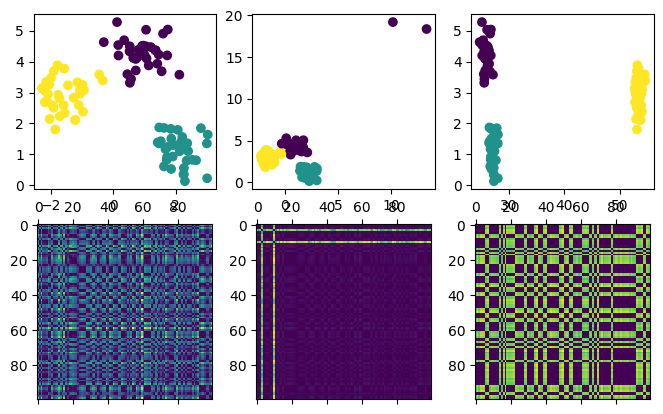

In [96]:
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(8, 5))
axs[0, 0].scatter(X[:, 0], X[:, 1], c=y)
axs[0, 1].scatter(X_1[:, 0], X_1[:, 1], c=y)
axs[0, 2].scatter(X_2[:, 0], X_2[:, 1], c=y)

axs[1, 0].matshow(m1, cmap='viridis')
axs[1, 1].matshow(m2, cmap='viridis')
axs[1, 2].matshow(m3, cmap='viridis')

### Question 2

We can also use other distance metrics such as L1 distance.
For pixel values $p_{ij}^{(k)}$ at location $(i,j)$ of some image $I_k$, 

the mean $\mu$ across all pixels over all images is $$\mu=\frac{1}{nhw}\sum_{k=1}^n\sum_{i=1}^{h}\sum_{j=1}^{w}p_{ij}^{(k)}$$
And the pixel-wise mean $\mu_{ij}$ across all images is 
$$\mu_{ij}=\frac{1}{n}\sum_{k=1}^np_{ij}^{(k)}.$$
The general standard deviation $\sigma$ and pixel-wise standard deviation $\sigma_{ij}$ is defined similarly.

Which of the following preprocessing steps will not change the performance of a Nearest Neighbor classifier that uses L1 distance? Select all that apply.
1. Subtracting the mean $\mu$ ($\tilde{p}_{ij}^{(k)}=p_{ij}^{(k)}-\mu$.)
2. Subtracting the per pixel mean $\mu_{ij}$  ($\tilde{p}_{ij}^{(k)}=p_{ij}^{(k)}-\mu_{ij}$.)
3. Subtracting the mean $\mu$ and dividing by the standard deviation $\sigma$.
4. Subtracting the pixel-wise mean $\mu_{ij}$ and dividing by the pixel-wise standard deviation $\sigma_{ij}$.
5. Rotating the coordinate axes of the data.

*Your Answer:*


*Your Explanation:*



1. Subtracting the mean $\mu$ ($\tilde{p}_{ij}^{(k)}=p_{ij}^{(k)}-\mu$.)

$$L=\sum_{ij} |(p_{ij}^{a}-\mu)-(p_{ij}^b-\mu) | = \sum_{ij}|p_{ij}^{a} - p_{ij}^{b}|$$

**Ответ: не влияет**

2. Subtracting the per pixel mean $\mu_{ij}$  ($\tilde{p}_{ij}^{(k)}=p_{ij}^{(k)}-\mu_{ij}$.)

$$L=\sum_{ij} |(p_{ij}^{a}-\mu_{ij})-(p_{ij}^b-\mu_{ij}) | = \sum_{ij}|p_{ij}^{a} - p_{ij}^{b}|$$

**Ответ: не влияет**

3. Subtracting the mean $\mu$ and dividing by the standard deviation $\sigma$.

**Ответ: не влияет, т.к. это тоже самое, что пункт 1, только нормированный на std**

4. Subtracting the pixel-wise mean $\mu_{ij}$ and dividing by the pixel-wise standard deviation $\sigma_{ij}$.

$$L=\sum_{ij} |(p_{ij}^{a}-\mu_{ij})-(p_{ij}^b-\mu_{ij}) | = \sum_{ij}|\frac{p_{ij}^{a}}{\sigma_{ij}} - \frac{p_{ij}^{b}}{\sigma_{ij}}|$$

**Ответ: влияет, мы получим расстояния с разными коэффициентами**

5. Rotating the coordinate axes of the data.

если имеется ввиду операция np.transpose(img, (...)), то не влияет, если же имеется ввиду поворот простанства то влияет.

## Question 3

Which of the following statements about $k$-Nearest Neighbor ($k$-NN) are true in a classification setting, and for all $k$? Select all that apply.
1. The decision boundary (hyperplane between classes in feature space) of the k-NN classifier is linear.
2. The training error of a 1-NN will always be lower than that of 5-NN.
3. The test error of a 1-NN will always be lower than that of a 5-NN.
4. The time needed to classify a test example with the k-NN classifier grows with the size of the training set.
5. None of the above.

*Your Answer:*
1. В общем случае нет. KNN не относится к линейным классификаторам, граница принятия решений может получиться достаточно размытой.
2. В общем случае нет. Ниже приведен контрпример. Классы сильно разделены, и классификатор одинаково хорошо работает и с 1 или 5 соседями. Ответ: 5-NN не будет лучше, чем 1-NN, но может быть не хуже.
4. Нет. 1-NN это просто запоминание меток, т.е. переобучение, 5-NN наврняка покажет лучшую обобщающую способность. 
5. Да. Чем больше примеров, тем больше операций нужно выполнить над матрицей расстояний.

In [25]:
# Контрпример к 2

In [3]:
from sklearn.datasets import make_blobs
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier

In [11]:
X, y = make_blobs(centers=2, cluster_std=0.5, random_state=0)

In [14]:
ind = np.where(y == 1)
X[ind,0] += 30
X[:,0] += 25

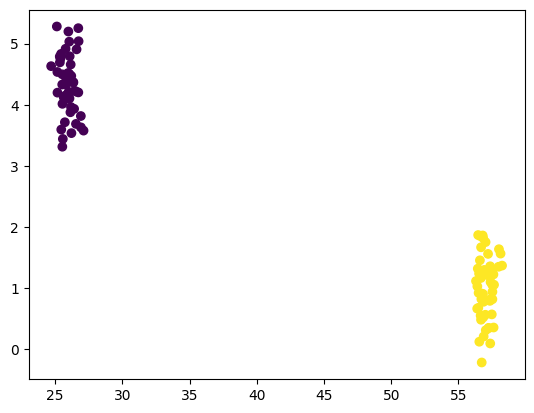

In [15]:
plt.scatter(X[:, 0], X[:, 1], c=y)

In [24]:
clf_1 = KNeighborsClassifier(n_neighbors=1)
clf_1.fit(X,y)

KNeighborsClassifier(n_neighbors=1)

In [21]:
clf_1.score(X,y)

1.0

In [22]:
clf_5 = KNeighborsClassifier(n_neighbors=5)
clf_5.fit(X,y)

KNeighborsClassifier()

In [23]:
clf_5.score(X,y)

1.0

In [26]:
# score это не то же, что ошибка, но sklearn не предоставляет аттрибут loss